In [182]:
import pandas as pd
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [184]:
df = pd.read_csv("../data/combined_data.csv", index_col="date", parse_dates=True)
df = df.dropna()
target = 'Close'
exog_cols = [
      'EMA_30', 'EMA_60', 'EMA_200',
      'rsi_14',
      'MACD', 'MACD_Signal', 'MACD_Histogram',
      'BB_Middle', 'BB_Upper', 'BB_Lower',
      'Momentum_10',

      'DTWEXBGS',   
      'OIL_PRICE',          
      'FEDFUNDS',           
      'CPIAUCSL',           

      # 'avg_sentiment_score',

      'Volume'
  ]

arima_train, holdout = train_test_split(df, test_size=0.4, shuffle=False)
lstm_train, test = train_test_split(holdout, test_size=0.4, shuffle=False)
y_train_arima, x_train_arima = arima_train[target], arima_train[exog_cols]
y_test_arima, x_test_arima = lstm_train[target], lstm_train[exog_cols]
y_fin_test, x_fin_test = test[target], test[exog_cols]

In [185]:
arima_model = SARIMAX(y_train_arima, exog=x_train_arima, order=(1, 1, 0))  
fitted_arima = arima_model.fit(disp=False, maxiter=100)  
arima_residuals = fitted_arima.resid

arima_pred_lstm_train = fitted_arima.forecast(steps=len(y_test_arima), exog=x_test_arima)

arima_pred_fin = fitted_arima.forecast(steps=len(y_fin_test), exog=x_fin_test)

/Users/koidejulian/miniconda3/envs/env_10301/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/koidejulian/miniconda3/envs/env_10301/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/koidejulian/miniconda3/envs/env_10301/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/koidejulian/miniconda3/envs/env_10301/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results w

In [186]:
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

In [187]:
rmse_lstm_train = rmse(y_test_arima, arima_pred_lstm_train)
mse = mean_squared_error(y_test_arima, arima_pred_lstm_train)
print(f"RMSE: {rmse}")
print(f"MSE: {mse}")

RMSE: <function rmse at 0x14ee8d670>
MSE: 2.8698809252604383


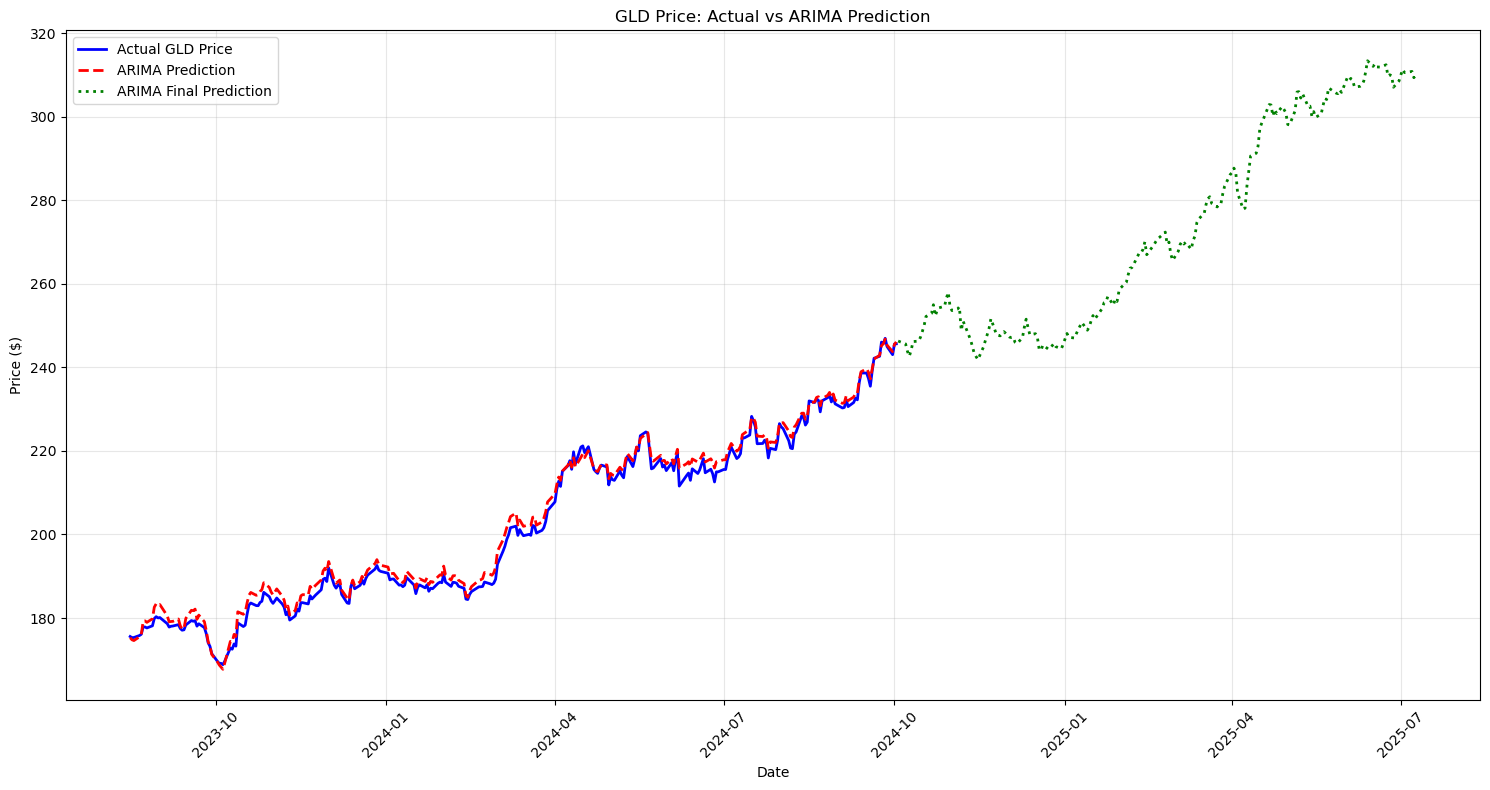

In [188]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plt.plot(y_test_arima.index, y_test_arima.values, label='Actual GLD Price', color='blue', linewidth=2)

plt.plot(y_test_arima.index, arima_pred_lstm_train.values, label='ARIMA Prediction', color='red', linewidth=2, linestyle='--')

plt.plot(y_fin_test.index, arima_pred_fin.values, label='ARIMA Final Prediction', color='green', linewidth=2, linestyle=':')

plt.title('GLD Price: Actual vs ARIMA Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [189]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import StandardScaler

In [190]:
lstm_residuals = y_test_arima.values - arima_pred_lstm_train.values
lstm_train_dates = y_test_arima.index

lstm_test_dates = y_fin_test.index 
lstm_test_vals = y_fin_test.values - arima_pred_fin.values

df_lstm_train = pd.DataFrame({
    'date': lstm_train_dates,
    'residuals': lstm_residuals
})

df_lstm_test = pd.DataFrame({
    'date': lstm_test_dates,
    'residuals': lstm_test_vals})

In [191]:
lstm_X_train, lstm_y_train = [], []
window_size = 14
features = ['residuals']
for i in range(len(df_lstm_train) - window_size):
    lstm_X_train.append(df_lstm_train[features].values[i: i + window_size])
    lstm_y_train.append(df_lstm_train['residuals'].values[i + window_size])

lstm_X_test, lstm_y_test = [], []
for i in range(len(df_lstm_test) - window_size):
    lstm_X_test.append(df_lstm_test[features].values[i: i + window_size])
    lstm_y_test.append(df_lstm_test['residuals'].values[i + window_size])

lstm_X_train = np.array(lstm_X_train)
lstm_y_train = np.array(lstm_y_train)
lstm_X_test = np.array(lstm_X_test)
lstm_y_test = np.array(lstm_y_test)

In [192]:
print("X shape after scaling:", lstm_X_train.shape)

X shape after scaling: (271, 14, 1)


In [193]:
if lstm_X_train.ndim == 2:
    lstm_X_train = lstm_X_train.reshape(lstm_X_train.shape[0], lstm_X_train.shape[1], 1)
    lstm_X_test  = lstm_X_test .reshape(lstm_X_test .shape[0], lstm_X_test .shape[1], 1)

n_train, window, d = lstm_X_train.shape
n_test = lstm_X_test.shape[0]

lstm_X_train = lstm_X_train.reshape(-1, d)
lstm_X_test = lstm_X_test.reshape(-1, d)
lstm_y_train = lstm_y_train.reshape(-1, 1)
lstm_y_test = lstm_y_test.reshape(-1, 1)

x_scaler = StandardScaler()
x_scaler.fit(lstm_X_train)
lstm_X_train = x_scaler.transform(lstm_X_train)
lstm_X_test = x_scaler.transform(lstm_X_test)

y_scaler = StandardScaler()
y_scaler.fit(lstm_y_train)
lstm_y_train = y_scaler.transform(lstm_y_train)
lstm_y_test = y_scaler.transform(lstm_y_test)

lstm_X_train = lstm_X_train.reshape(n_train, window, d)
lstm_X_test = lstm_X_test.reshape(n_test, window, d)

lstm_y_train = lstm_y_train.reshape(n_train, 1)
lstm_y_test = lstm_y_test.reshape(n_test, 1)

In [201]:
class LSTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = LSTMDataset(lstm_X_train, lstm_y_train)
test_dataset = LSTMDataset(lstm_X_test, lstm_y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [204]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  
        return self.fc(lstm_out)

input_size = 1
hidden_size = 16
output_size = 1
model = LSTMModel(input_size, hidden_size, output_size, dropout=0.5)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

In [205]:
import numpy as np
n_epochs = 1000

for epoch in range(1, n_epochs+1):
    model.train()
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(Xb)
        loss   = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

    if epoch % 100 == 0:
        model.eval()

        def evaluate(loader):
            preds, trues = [], []
            with torch.no_grad():
                for Xb, yb in loader:
                    y_hat = model(Xb)
                    preds.append(y_hat.cpu().numpy())
                    trues.append(yb.cpu().numpy())
            return np.concatenate(preds), np.concatenate(trues)

        train_preds, train_trues = evaluate(train_loader)
        train_rmse = np.sqrt(np.mean((train_preds - train_trues)**2))

        test_preds, test_trues   = evaluate(test_loader)
        test_rmse  = np.sqrt(np.mean((test_preds  - test_trues )**2))

        print(f"Epoch {epoch:04d} — Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")

Epoch 0100 — Train RMSE: 0.5270, Test RMSE: 2.0648
Epoch 0200 — Train RMSE: 0.5093, Test RMSE: 2.2088
Epoch 0300 — Train RMSE: 0.3208, Test RMSE: 2.2239
Epoch 0400 — Train RMSE: 0.1888, Test RMSE: 2.3888
Epoch 0500 — Train RMSE: 0.1503, Test RMSE: 2.4734
Epoch 0600 — Train RMSE: 0.1192, Test RMSE: 2.5426
Epoch 0700 — Train RMSE: 0.0934, Test RMSE: 2.6242
Epoch 0800 — Train RMSE: 0.0818, Test RMSE: 2.6512
Epoch 0900 — Train RMSE: 0.0684, Test RMSE: 2.6483
Epoch 1000 — Train RMSE: 0.0830, Test RMSE: 2.6278


In [206]:
model.eval()
with torch.no_grad():
    train_pred = model(train_dataset.X).cpu().numpy().flatten()
    test_pred = model(test_dataset.X).cpu().numpy().flatten()

train_pred = y_scaler.inverse_transform(train_pred.reshape(-1, 1)).flatten()
test_pred = y_scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()

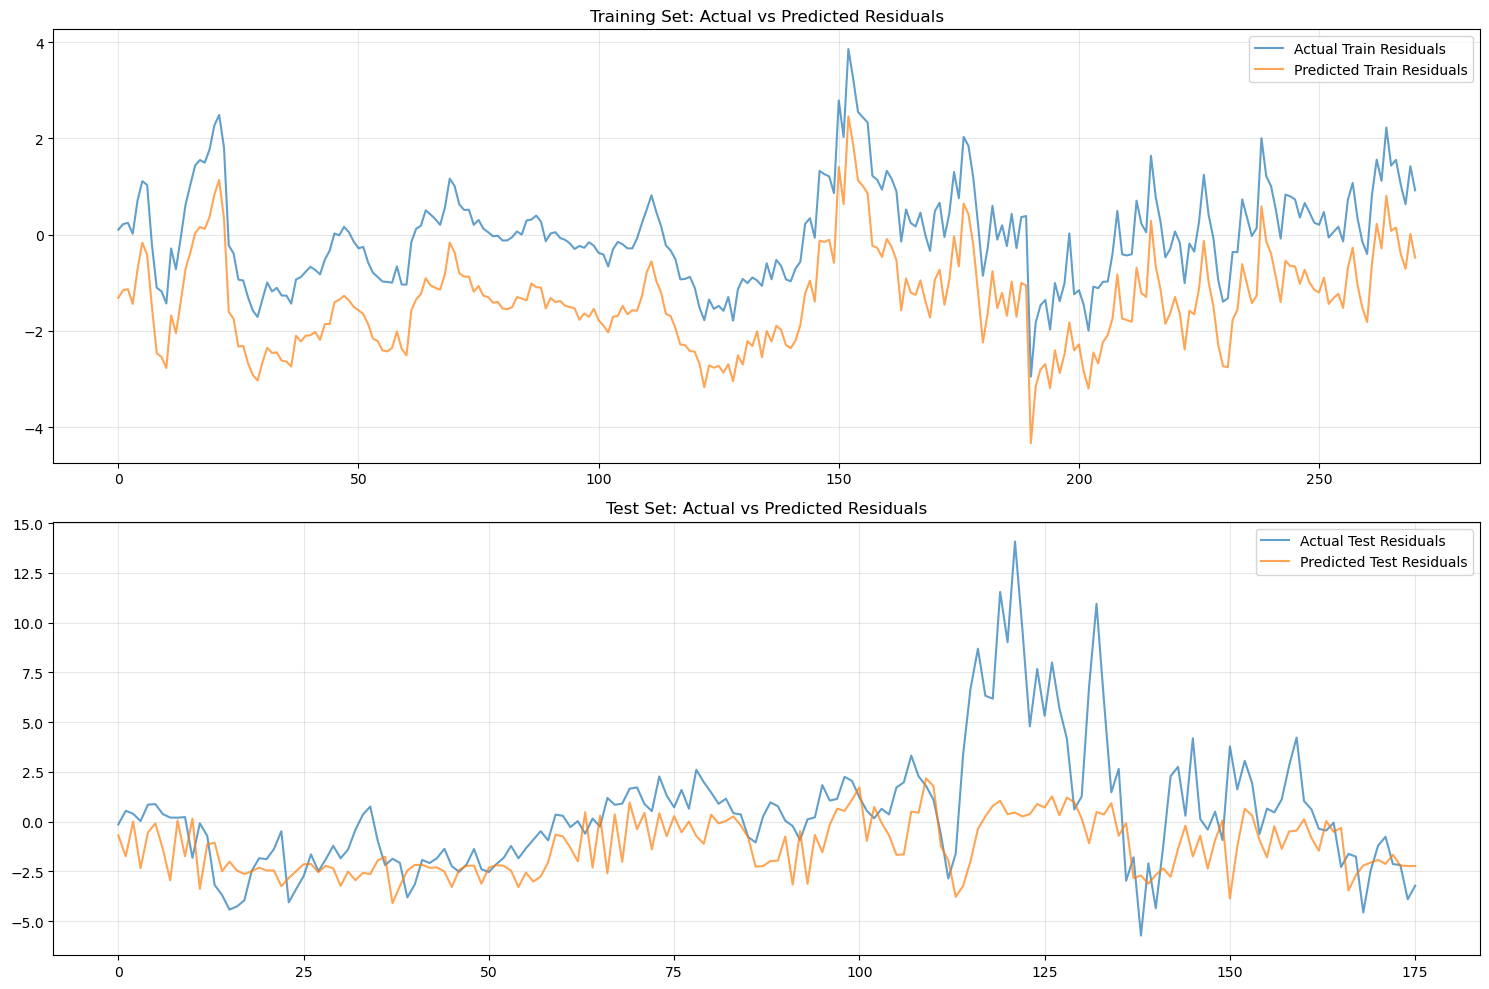

Train RMSE: 1.9688
Test RMSE: 3.7927


In [207]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(train_dataset.y.cpu().numpy(), label='Actual Train Residuals', alpha=0.7)
plt.plot(train_pred, label='Predicted Train Residuals', alpha=0.7)
plt.title('Training Set: Actual vs Predicted Residuals')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(test_dataset.y.cpu().numpy(), label='Actual Test Residuals', alpha=0.7)
plt.plot(test_pred, label='Predicted Test Residuals', alpha=0.7)
plt.title('Test Set: Actual vs Predicted Residuals')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Train RMSE: {np.sqrt(np.mean((train_dataset.y.cpu().numpy() - train_pred)**2)):.4f}")
print(f"Test RMSE: {np.sqrt(np.mean((test_dataset.y.cpu().numpy() - test_pred)**2)):.4f}")

In [208]:
final_predictions = arima_pred_fin.iloc[14:] + test_pred
final_real = y_fin_test.values[14:]
final_dates = df_lstm_test['date'].iloc[14:]


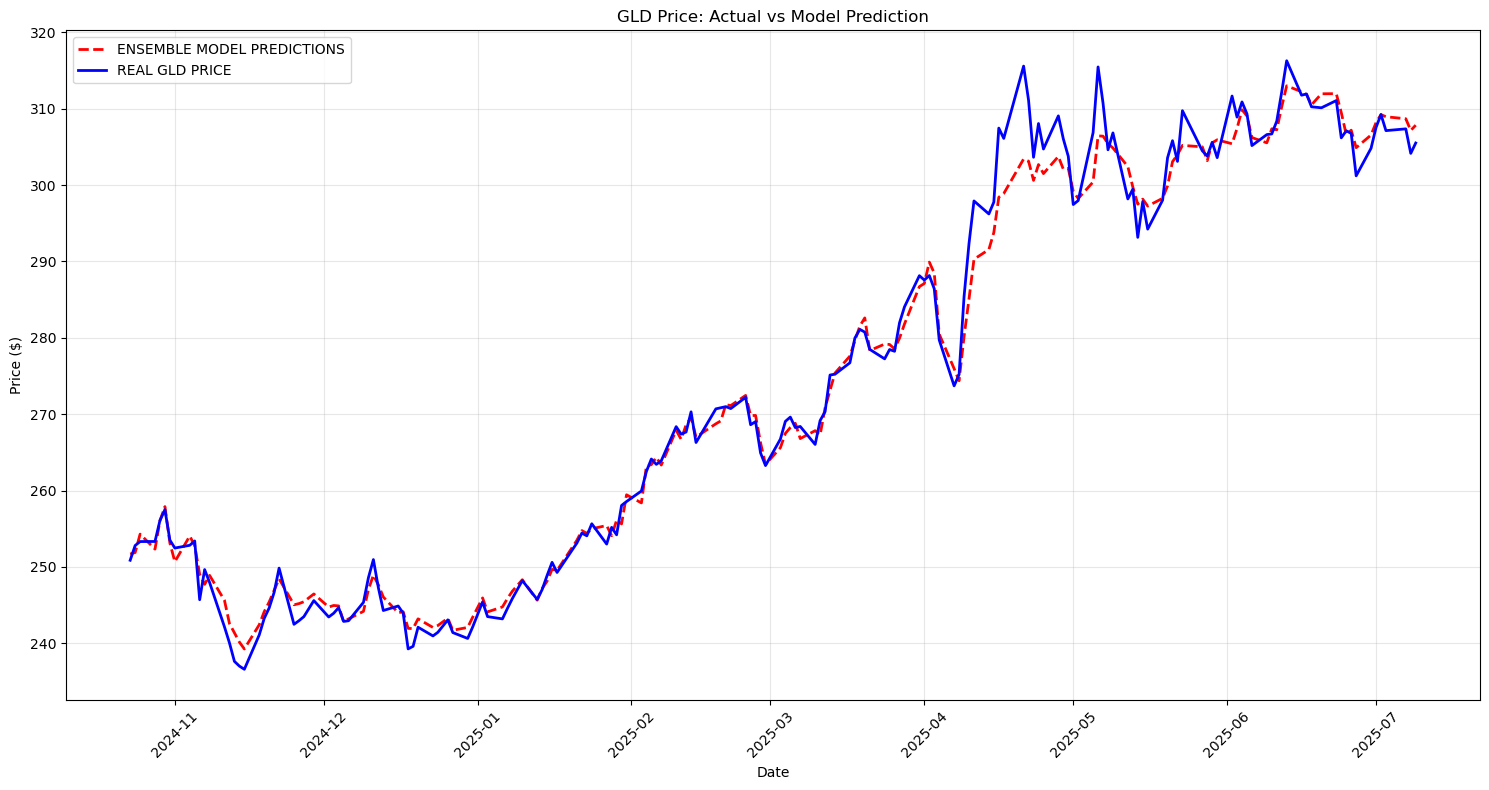

Final rmse: 2.6118597588612187
Final mse: 6.821811399958583


In [209]:
plt.figure(figsize=(15, 8))

plt.plot(final_dates, final_predictions, label='ENSEMBLE MODEL PREDICTIONS', color='red', linewidth=2, linestyle='--')
plt.plot(final_dates, final_real, label='REAL GLD PRICE', color='blue', linewidth=2)

plt.title('GLD Price: Actual vs Model Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Final rmse:", np.sqrt(np.mean((final_predictions - final_real)**2)))
print("Final mse:", mean_squared_error(final_real, final_predictions))